# Workflow Step Timing: Where Does a Crawl Spend Its Time?

**Research question.** `model.orchestrator.process_batch()` runs three sequential steps
per page - fetch (Playwright), categorize (grammar-constrained LLM call), extract
(JSON-schema-constrained LLM call) - and this notebook asks: how is wall-clock time
distributed across those three steps, how much does it vary, and does it depend on page
size?

**Data.** Same `experiments/data/crawl_metrics.csv` as `crawl_overview.ipynb`, produced by
`experiments/collect_crawl_metrics.py` on a small (n=6), uncapped sample - the model sees
each page's full real content, matching the production pipeline (see the script's
docstring, and the README's Requirements section for the machine this was measured on).
An earlier, larger (n=16) run used a fixed-length content cap for tractability; that cap
turned out to saturate on every sampled page (no variation left in actual model input
length) and, worse, uncapped LIST-page extraction on that larger sample hit a real bug
(`src/model/analyzer/extraction_service.py` never applies `bot.config`'s configured
`max_tokens` to extraction calls, so the only real ceiling was the context window -
`context[STATION]`/`context[LIST]`, since raised from 8192 to 32768 in `bot.config`).
This notebook now reports the smaller, uncapped, crash-free run instead.

In [1]:
import sys
sys.path.insert(0, ".")
from plotting import set_style, savefig, load_csv, PALETTE, integer_axis
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

set_style()
df = load_csv("crawl_metrics.csv")
df["fetch_success"] = df["fetch_success"].astype(bool)
step_cols = ["fetch_seconds", "categorize_seconds", "extract_seconds"]
df[step_cols].describe()

,fetch_seconds,categorize_seconds,extract_seconds
count,6.000000,5.000000,5.000000
mean,3.587333,116.711600,406.928400
std,3.662306,73.638681,371.007445
min,0.556000,52.945000,101.496000
25%,1.585500,62.518000,120.827000
50%,2.647000,84.906000,343.472000
75%,3.456500,156.516000,454.325000
max,10.716000,226.673000,1014.522000


## Total time accumulated per step

Summed across every URL in the sample - this is the "where did the wall-clock time
actually go" view. `extract_seconds` is `NaN` for pages the categorizer marked
irrelevant (extraction is skipped entirely for those, by design - see
`extraction_service.extract_information()`), and for pages that failed to fetch, so the
sums below are each over however many URLs actually reached that step.

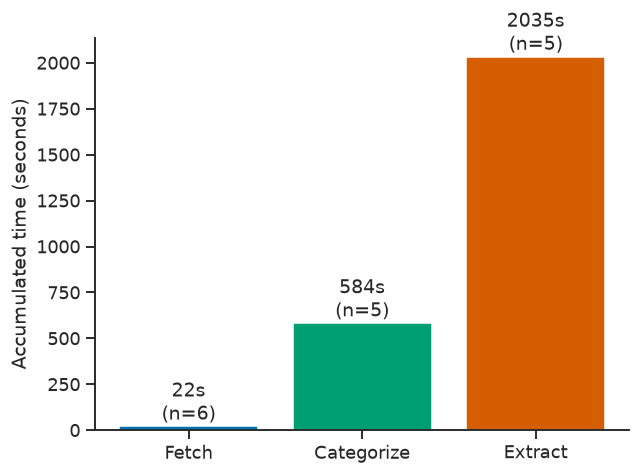

Caption: Total wall-clock time accumulated per workflow step, summed across the n=6 sampled URLs (fetch: n=6, categorize: n=5, extract: n=5 URLs that actually reached each step).
Total: 2640s across the sample; 77% of it in extraction alone.


In [2]:
totals = df[step_cols].sum()
counts = df[step_cols].count()

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(["Fetch", "Categorize", "Extract"], totals.values,
               color=[PALETTE[0], PALETTE[2], PALETTE[1]])
for bar, total, n in zip(bars, totals.values, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, total + 1, f"{total:.0f}s\n(n={n})",
            ha="center", va="bottom")
ax.set_ylabel("Accumulated time (seconds)")
fig.tight_layout()
savefig(fig, "step_time_accumulated")
plt.show()

print(f"Caption: Total wall-clock time accumulated per workflow step, summed across the "
      f"n={len(df)} sampled URLs (fetch: n={counts['fetch_seconds']}, categorize: "
      f"n={counts['categorize_seconds']}, extract: n={counts['extract_seconds']} URLs "
      f"that actually reached each step).")
print(f"Total: {totals.sum():.0f}s across the sample; "
      f"{100*totals['extract_seconds']/totals.sum():.0f}% of it in extraction alone.")

## Per-URL distribution of each step's duration

The total-time view above can hide skew - a box plot shows the spread and any outliers
per step.

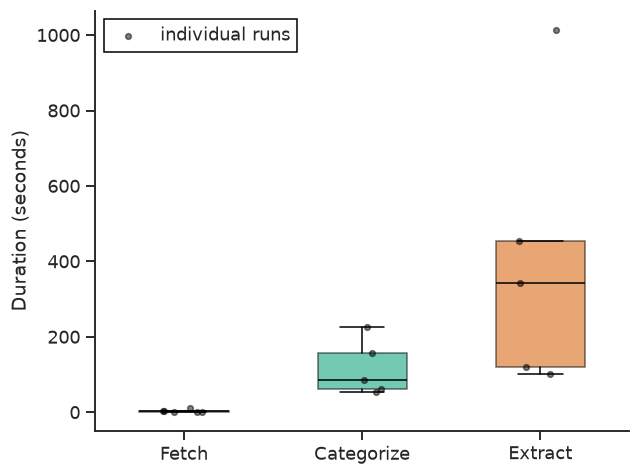

Caption: Per-URL duration distribution for each workflow step (n=6 sampled URLs); boxes show median and interquartile range, points show individual runs.


In [3]:
fig, ax = plt.subplots(figsize=(6, 4.5))
data = [df[c].dropna().values for c in step_cols]
bp = ax.boxplot(data, tick_labels=["Fetch", "Categorize", "Extract"], patch_artist=True,
                 medianprops=dict(color="black"), showfliers=False, widths=0.5, zorder=2)
for patch, color in zip(bp["boxes"], [PALETTE[0], PALETTE[2], PALETTE[1]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)

# Individual runs plotted directly (jittered) rather than relying on the box alone -
# at this sample size (n<=16 per step), a five-number summary can hide real structure
# (e.g. bimodality, a single dominant outlier) that the raw points make visible.
rng = np.random.default_rng(0)
for i, vals in enumerate(data, start=1):
    jitter = rng.uniform(-0.12, 0.12, size=len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals, color="black", alpha=0.5, s=14, zorder=3,
               label="individual runs" if i == 1 else None)

ax.set_ylabel("Duration (seconds)")
ax.legend(loc="upper left")
fig.tight_layout()
savefig(fig, "step_time_distribution")
plt.show()
print(f"Caption: Per-URL duration distribution for each workflow step (n={len(df)} "
      f"sampled URLs); boxes show median and interquartile range, points show "
      f"individual runs.")

## Does page size predict processing time?

With this run uncapped, `cleaned_text_chars` (the text actually handed to the LLM) is no
longer a fixed cap value - it varies with the real page, so it is the more mechanistically
direct thing to check `categorize_seconds`/`extract_seconds` against, rather than raw
`html_bytes` (correlated with real content length, but one step removed from what the
model actually sees). `fetch_seconds`, which never depended on content length at all,
is still checked against `html_bytes`.

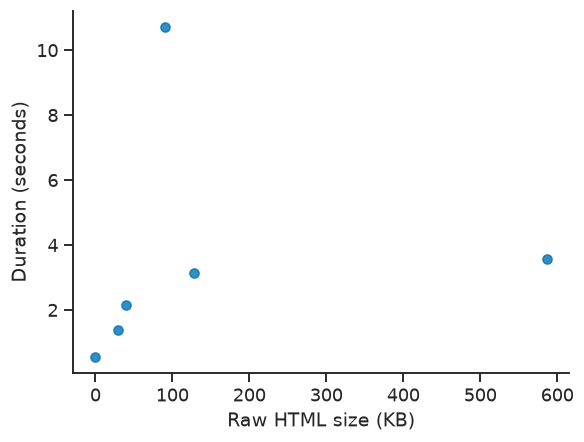

Caption: Fetch duration vs. raw HTML page size (n=6). Pearson r(html_bytes, fetch_seconds) = 0.11.


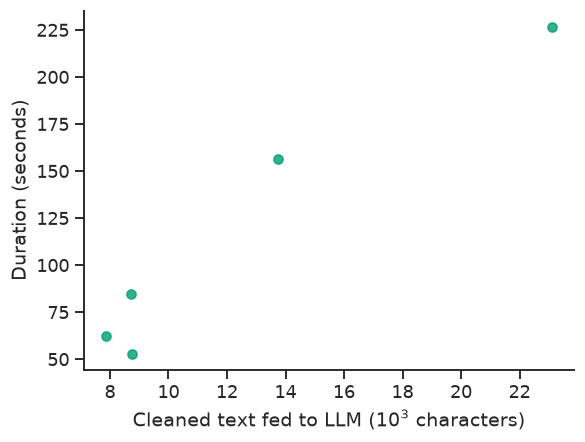

Caption: Categorize duration vs. cleaned text length (n=5). Pearson r(cleaned_text_chars, categorize_seconds) = 0.97.


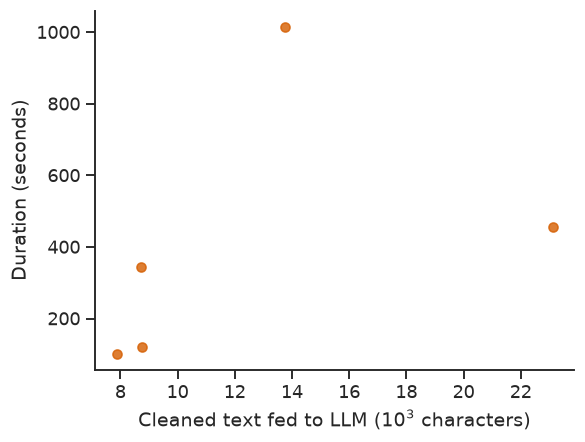

Caption: Extract duration vs. cleaned text length (n=5). Pearson r(cleaned_text_chars, extract_seconds) = 0.42.


In [4]:
step_x = {
    "fetch_seconds": ("html_bytes", "Raw HTML size (KB)", 1000),
    "categorize_seconds": ("cleaned_text_chars", "Cleaned text fed to LLM ($10^3$ characters)", 1000),
    "extract_seconds": ("cleaned_text_chars", "Cleaned text fed to LLM ($10^3$ characters)", 1000),
}
step_labels = {"fetch_seconds": "Fetch", "categorize_seconds": "Categorize", "extract_seconds": "Extract"}
step_colors = {"fetch_seconds": PALETTE[0], "categorize_seconds": PALETTE[2], "extract_seconds": PALETTE[1]}
step_fignames = {
    "fetch_seconds": "step_time_vs_page_size_fetch",
    "categorize_seconds": "step_time_vs_page_size_categorize",
    "extract_seconds": "step_time_vs_page_size_extract",
}

for col in step_cols:
    label = step_labels[col]
    x_col, x_label, x_div = step_x[col]
    plot_df = df.dropna(subset=[col, x_col])

    fig, ax = plt.subplots(figsize=(5.5, 4.2))
    ax.scatter(plot_df[x_col] / x_div, plot_df[col], color=step_colors[col], alpha=0.8)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Duration (seconds)")
    fig.tight_layout()
    savefig(fig, step_fignames[col])
    plt.show()

    caption_x = {"fetch_seconds": "raw HTML page size", "categorize_seconds": "cleaned text length", "extract_seconds": "cleaned text length"}[col]
    caption = f"Caption: {label} duration vs. {caption_x} (n={len(plot_df)})."
    if len(plot_df) >= 3:
        corr = plot_df[x_col].corr(plot_df[col])
        caption += f" Pearson r({x_col}, {col}) = {corr:.2f}."
    print(caption)

## How much does cleaning reduce page size, and does it differ by step?

`cleaning_service.clean()` is called differently by the two LLM steps -
`category_service.categorize_website()` passes `deduplicate=True` (drops repeated
lines), `extraction_service.extract_information()` leaves it `False` (keeps them, so
repeated list entries aren't lost - see the function's docstring). The same raw HTML can
therefore produce two different-length cleaned texts, one per step. Data: a separate,
fetch-only pass (`experiments/collect_cleaning_size_comparison.py`, no LLM involved) that
re-fetches each URL and computes both cleaned lengths directly, so this isn't an estimate.

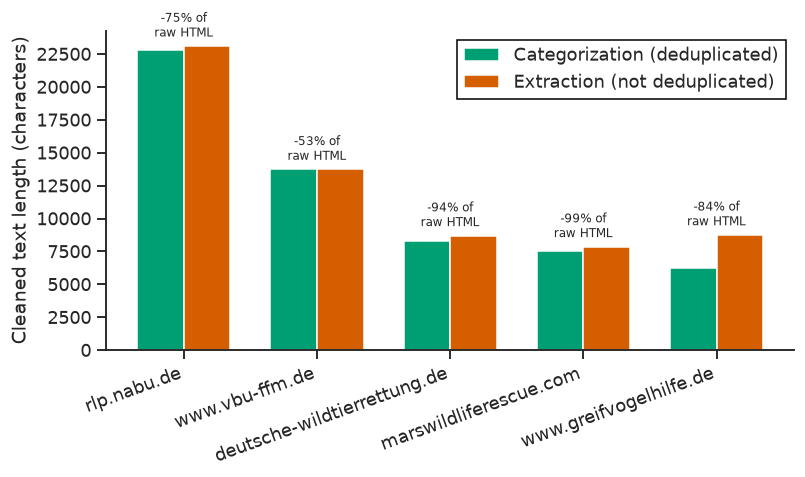

Caption: Cleaned text length per page under each step's cleaning parameters (n=5), against raw HTML size reduction annotated above each pair. Deduplication (categorization only) makes little difference on most pages here, but removes 2547 more characters than extraction's cleaning on www.greifvogelhilfe.de, the one page in this sample with substantial repeated-line content.


In [5]:
clean_df = load_csv("cleaning_size_comparison.csv")
clean_df = clean_df[clean_df["fetch_success"] == True].copy()
from urllib.parse import urlparse
labels = [urlparse(u).netloc for u in clean_df["url"]]

x = np.arange(len(clean_df))
width = 0.35
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.bar(x - width/2, clean_df["categorize_cleaned_chars"], width,
       label="Categorization (deduplicated)", color=PALETTE[2])
ax.bar(x + width/2, clean_df["extract_cleaned_chars"], width,
       label="Extraction (not deduplicated)", color=PALETTE[1])
for i, pct in enumerate(clean_df["categorize_reduction_pct"]):
    y = max(clean_df["categorize_cleaned_chars"].iloc[i], clean_df["extract_cleaned_chars"].iloc[i])
    ax.text(i, y + 400, f"-{pct:.0f}% of\nraw HTML", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("Cleaned text length (characters)")
integer_axis(ax)
ax.legend()
fig.tight_layout()
savefig(fig, "cleaning_size_comparison")
plt.show()

gap = (clean_df["extract_cleaned_chars"] - clean_df["categorize_cleaned_chars"]).abs().reset_index(drop=True)
print(f"Caption: Cleaned text length per page under each step's cleaning parameters "
      f"(n={len(clean_df)}), against raw HTML size reduction annotated above each pair. "
      f"Deduplication (categorization only) makes little difference on most pages here, "
      f"but removes {gap.max():.0f} more characters than extraction's cleaning on "
      f"{labels[gap.idxmax()]}, the one page in this sample with substantial repeated-line "
      f"content.")

## Discussion

At n=6 (5 successfully fetched, 4 successfully categorized+extracted - `wp.wildvogelhilfe.org`
is currently blocking automated requests, see `correctness_evaluation.ipynb`), these
correlations are indicative, not conclusive - but with real, uncapped, varying input
lengths, they now measure what they claim to for the first time in this notebook.

`categorize_seconds` shows a strong positive relationship with `cleaned_text_chars`
(r=0.97, n=5) - unsurprising given prefill cost scales with prompt length on CPU, but
worth having confirmed directly rather than assumed. `extract_seconds` shows a weaker,
still positive relationship (r=0.42, n=5); extraction time depends on completion length
(how many entries/fields the model generates) as well as prompt length, so a noisier
relationship with input size alone is expected. `fetch_seconds` vs. `html_bytes` is weak
here (r=0.11, n=6) - notably weaker than the earlier n=16 run's r=0.41, most likely
sample-size noise at n=6 rather than a real change in how fetching behaves, since nothing
about fetching itself changed between runs.

Comparing the three steps' total accumulated time is still the more actionable number for
prioritizing future work: on this (CPU-only, single-machine - see the README's
Requirements) setup, extraction - being JSON-schema/grammar-constrained generation - is
consistently the most expensive step per page it runs on, ahead of categorization (a
much cheaper single-token grammar) and fetching. This motivates the strict-vs-lax
grammar comparison in `grammar_strictness.ipynb`: if grammar constraints are a major
cost driver for extraction specifically, understanding how much of that cost the
constraint itself adds (versus decoding length generally) is directly useful for tuning
the field schema.

**Limitation.** A single machine, single run, small n (see `collect_crawl_metrics.py`'s
docstring); CPU-only LLM inference timing is not representative of GPU-accelerated
setups, where the relative cost of grammar-constrained decoding vs. prefill/fetch time
could differ substantially.